# Webscaping of Wikipedia Webpages

https://en.wikipedia.org/wiki/World_population

## Step 1 - Get HTML Content from url

In [1]:
import requests

In [2]:
url = "https://en.wikipedia.org/wiki/World_population"
header = {"User-Agent": "Chrome/127.0.0.1"}
response = requests.get(url=url, headers=header)

In [3]:
print(response.status_code)

200


### If response is 200 you are ok to fetch the results

In [4]:
response.raise_for_status

<bound method Response.raise_for_status of <Response [200]>>

In [5]:
print(response.content[0:1000])

b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>World population - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled ve

In [6]:
from bs4 import BeautifulSoup

In [7]:
soup = BeautifulSoup(response.content)
print(type(soup))

<class 'bs4.BeautifulSoup'>


## Show the title of webpage

In [8]:
title_tag = soup.find(name="title")
title_tag

<title>World population - Wikipedia</title>

In [9]:
title_tag.text

'World population - Wikipedia'

### How inspect page on chrome


1. Right click page -> Inspect


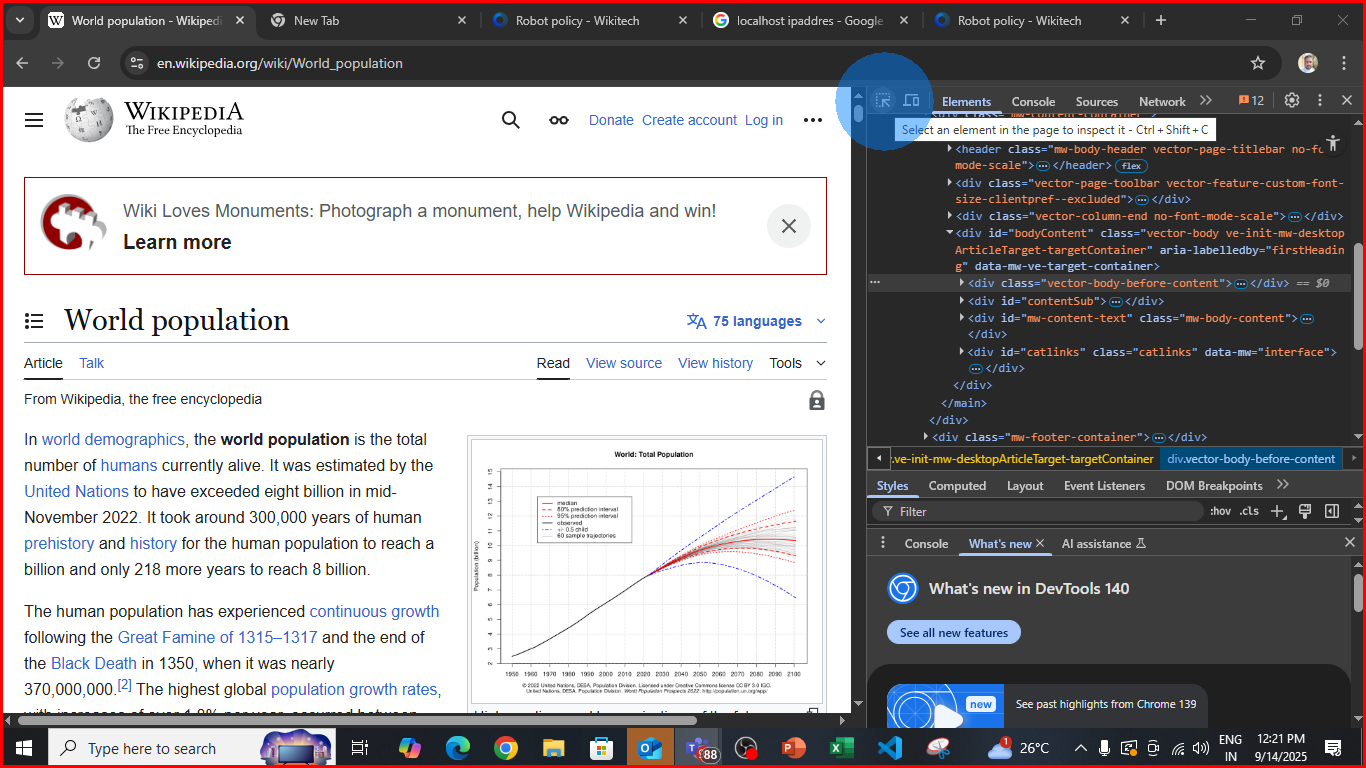

In [10]:
h1_tag = soup.find(name="h1", class_="firstHeading")
h1_tag

<h1 class="firstHeading mw-first-heading" id="firstHeading"><span class="mw-page-title-main">World population</span></h1>

In [11]:
h1_tag.text

'World population'

## Get all Subheadings

In [12]:
subheading_tags = soup.find_all(name="div", class_="mw-heading")
subheading_tags

[<div class="mw-heading mw-heading2"><h2 id="History">History</h2></div>,
 <div class="mw-heading mw-heading3"><h3 id="Prehistoric_patterns">Prehistoric patterns</h3></div>,
 <div class="mw-heading mw-heading3"><h3 id="Ancient_and_post-classical_history">Ancient and post-classical history</h3></div>,
 <div class="mw-heading mw-heading3"><h3 id="Modern_history">Modern history</h3></div>,
 <div class="mw-heading mw-heading3"><h3 id="20th_century">20th century</h3></div>,
 <div class="mw-heading mw-heading3"><h3 id="Milestones_by_the_billions">Milestones by the billions</h3></div>,
 <div class="mw-heading mw-heading2"><h2 id="Global_demographics">Global demographics</h2></div>,
 <div class="mw-heading mw-heading2"><h2 id="Population_by_region">Population by region</h2></div>,
 <div class="mw-heading mw-heading2"><h2 id="Largest_populations_by_country">Largest populations by country</h2></div>,
 <div class="mw-heading mw-heading3"><h3 id="Ten_most_populous_countries">Ten most populous coun

In [13]:
subheading_tags[0]

<div class="mw-heading mw-heading2"><h2 id="History">History</h2></div>

In [14]:
subheading_tags[0].text

'History'

In [15]:
subheading_texts = [tag.text for tag in subheading_tags]
subheading_texts

['History',
 'Prehistoric patterns',
 'Ancient and post-classical history',
 'Modern history',
 '20th century',
 'Milestones by the billions',
 'Global demographics',
 'Population by region',
 'Largest populations by country',
 'Ten most populous countries',
 'Most densely populated countries',
 'Fluctuation',
 'Annual population growth',
 'Population growth by region',
 'Past population',
 'Projections',
 'Mathematical approximations',
 'Years for world population to double',
 'Number of humans who have ever lived',
 'Human population as a function of food availability',
 'See also',
 'Explanatory notes',
 'References',
 'Citations',
 'General and cited sources',
 'Further reading',
 'External links']

## Get the paragraphs from the entire page

In [16]:
p_tags = soup.find_all(name="p")

In [17]:
p_tags

[<p class="mw-empty-elt">
 </p>,
 <p>In <a href="/wiki/Demographics_of_the_world" title="Demographics of the world">world demographics</a>, the <b>world population</b> is the total number of <a href="/wiki/Human" title="Human">humans</a> currently alive. It was estimated by the <a href="/wiki/United_Nations" title="United Nations">United Nations</a> to have exceeded eight billion in mid-November 2022. It took around 300,000 years of human <a href="/wiki/Prehistory" title="Prehistory">prehistory</a> and <a href="/wiki/Human_history" title="Human history">history</a> for the human population to reach a billion and only 218 more years to reach 8 billion.
 </p>,
 <p>The human population has experienced <a href="/wiki/Population_growth" title="Population growth">continuous growth</a> following the <a href="/wiki/Great_Famine_of_1315%E2%80%931317" title="Great Famine of 1315–1317">Great Famine of 1315–1317</a> and the end of the <a href="/wiki/Black_Death" title="Black Death">Black Death</a>

In [18]:
p_tags[0:3]

[<p class="mw-empty-elt">
 </p>,
 <p>In <a href="/wiki/Demographics_of_the_world" title="Demographics of the world">world demographics</a>, the <b>world population</b> is the total number of <a href="/wiki/Human" title="Human">humans</a> currently alive. It was estimated by the <a href="/wiki/United_Nations" title="United Nations">United Nations</a> to have exceeded eight billion in mid-November 2022. It took around 300,000 years of human <a href="/wiki/Prehistory" title="Prehistory">prehistory</a> and <a href="/wiki/Human_history" title="Human history">history</a> for the human population to reach a billion and only 218 more years to reach 8 billion.
 </p>,
 <p>The human population has experienced <a href="/wiki/Population_growth" title="Population growth">continuous growth</a> following the <a href="/wiki/Great_Famine_of_1315%E2%80%931317" title="Great Famine of 1315–1317">Great Famine of 1315–1317</a> and the end of the <a href="/wiki/Black_Death" title="Black Death">Black Death</a>

In [19]:
p_text = [tag.text for tag in p_tags]

In [20]:
p_text

['\n',
 'In world demographics, the world population is the total number of humans currently alive. It was estimated by the United Nations to have exceeded eight billion in mid-November 2022. It took around 300,000 years of human prehistory and history for the human population to reach a billion and only 218 more years to reach 8\xa0billion.\n',
 'The human population has experienced continuous growth following the Great Famine of 1315–1317 and the end of the Black Death in 1350, when it was nearly 370,000,000.[2] The highest global population growth rates, with increases of over 1.8% per year, occurred between 1955 and 1975, peaking at 2.1% between 1965 and 1970.[3] The growth rate declined to 1.1% between 2015 and 2020 and is projected to decline further in the 21st century.[4] The global population is still increasing, but there is significant uncertainty about its long-term trajectory due to changing fertility and mortality rates.[5] The UN Department of Economics and Social Affair

In [21]:
p_text[0:3]

['\n',
 'In world demographics, the world population is the total number of humans currently alive. It was estimated by the United Nations to have exceeded eight billion in mid-November 2022. It took around 300,000 years of human prehistory and history for the human population to reach a billion and only 218 more years to reach 8\xa0billion.\n',
 'The human population has experienced continuous growth following the Great Famine of 1315–1317 and the end of the Black Death in 1350, when it was nearly 370,000,000.[2] The highest global population growth rates, with increases of over 1.8% per year, occurred between 1955 and 1975, peaking at 2.1% between 1965 and 1970.[3] The growth rate declined to 1.1% between 2015 and 2020 and is projected to decline further in the 21st century.[4] The global population is still increasing, but there is significant uncertainty about its long-term trajectory due to changing fertility and mortality rates.[5] The UN Department of Economics and Social Affair

# Saving the paras content in txt file 

In [22]:
with open("world_pop.txt", "w", encoding="utf-8") as f:
    f.writelines(p_text)

# Get the image links from page

In [23]:
a_tags = soup.find_all(name="a", class_="mw-file-description")
a_tags

[<a class="mw-file-description" href="/wiki/File:World_Population_Prospects.svg"><img class="mw-file-element" data-file-height="676" data-file-width="900" decoding="async" height="263" src="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/500px-World_Population_Prospects.svg.png" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/525px-World_Population_Prospects.svg.png 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/700px-World_Population_Prospects.svg.png 2x" width="350"/></a>,
 <a class="mw-file-description" href="/wiki/File:Illustration_of_contemporary_and_past_human_populations_Our_World_in_Data.png"><img class="mw-file-element" data-file-height="7747" data-file-width="5201" decoding="async" height="447" src="//upload.wikimedia.org/wikipedia/commons/thumb/d/d2/Illustration_of_contemporary_and_past_human_populations_Our_World_in_Data.png/330px-Illustration_of_contempor

In [24]:
a_tags[0]

<a class="mw-file-description" href="/wiki/File:World_Population_Prospects.svg"><img class="mw-file-element" data-file-height="676" data-file-width="900" decoding="async" height="263" src="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/500px-World_Population_Prospects.svg.png" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/525px-World_Population_Prospects.svg.png 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/700px-World_Population_Prospects.svg.png 2x" width="350"/></a>

In [25]:
a_tags[0].get("href")

'/wiki/File:World_Population_Prospects.svg'

In [26]:
home_page = "https://en.wikipedia.org"

In [27]:
home_page + a_tags[0].get("href")

'https://en.wikipedia.org/wiki/File:World_Population_Prospects.svg'

In [28]:
Image_urls = [home_page + tag.get("href") for tag in a_tags]

In [29]:
Image_urls

['https://en.wikipedia.org/wiki/File:World_Population_Prospects.svg',
 'https://en.wikipedia.org/wiki/File:Illustration_of_contemporary_and_past_human_populations_Our_World_in_Data.png',
 'https://en.wikipedia.org/wiki/File:2020_1million_cities.jpg',
 'https://en.wikipedia.org/wiki/File:Expectancy_of_life.svg',
 'https://en.wikipedia.org/wiki/File:Population_pyramid_of_the_world_in_continental_groupings_2023.svg',
 'https://en.wikipedia.org/wiki/File:Global_population_cartogram.png',
 'https://en.wikipedia.org/wiki/File:People%27s_-Km%C2%B2_for_all_countries_(and_us_states,_uk_kingdoms).png',
 'https://en.wikipedia.org/wiki/File:Top_5_Country_Population_Graph_1901_to_2021.svg',
 'https://en.wikipedia.org/wiki/File:Population_Density,_v4.11,_2020_(48009093621).jpg',
 'https://en.wikipedia.org/wiki/File:World_population_(UN).svg',
 'https://en.wikipedia.org/wiki/File:Total_Fertility_Rate_Map_by_Country.svg',
 'https://en.wikipedia.org/wiki/File:World_population_counter,_Eureka,_Halifax,_

In [30]:
img_tags = soup.find_all("img", class_="mw-file-element")
img_tags

[<img alt="Page semi-protected" class="mw-file-element" data-file-height="512" data-file-width="512" decoding="async" height="20" src="//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/20px-Semi-protection-shackle.svg.png" srcset="//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-protection-shackle.svg/40px-Semi-protection-shackle.svg.png 1.5x" width="20"/>,
 <img class="mw-file-element" data-file-height="676" data-file-width="900" decoding="async" height="263" src="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/500px-World_Population_Prospects.svg.png" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/525px-World_Population_Prospects.svg.png 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/700px-World_Population_Prospects.svg.png 2x" width="350"/>,
 <img class="mw-file-element" data-file-height="7747" data-file-width="5201" decoding="async" he

In [31]:
img_tags[1]

<img class="mw-file-element" data-file-height="676" data-file-width="900" decoding="async" height="263" src="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/500px-World_Population_Prospects.svg.png" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/525px-World_Population_Prospects.svg.png 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/700px-World_Population_Prospects.svg.png 2x" width="350"/>

In [32]:
url1 = "https:" + img_tags[1].get("src")
print(url1)

https://upload.wikimedia.org/wikipedia/commons/thumb/0/0e/World_Population_Prospects.svg/500px-World_Population_Prospects.svg.png


## Get all the tables

In [33]:
table_tags = soup.find_all(name="table", class_="wikitable")
table_tags[0:2]

[<table class="wikitable" style="text-align:center; float:right; clear:right; margin-left:8px; margin-right:0;">
 <caption>World population milestones in billions<sup class="reference" id="cite_ref-:6_61-0"><a href="#cite_note-:6-61"><span class="cite-bracket">[</span>61<span class="cite-bracket">]</span></a></sup> (Worldometers estimates)
 </caption>
 <tbody><tr>
 <th scope="row">Population
 </th>
 <th scope="col">1
 </th>
 <th scope="col">2
 </th>
 <th scope="col">3
 </th>
 <th scope="col">4
 </th>
 <th scope="col">5
 </th>
 <th scope="col">6
 </th>
 <th scope="col">7
 </th>
 <th scope="col">8
 </th>
 <th scope="col">9
 </th>
 <th scope="col">10
 </th></tr>
 <tr>
 <th scope="row">Year
 </th>
 <td>1804</td>
 <td>1927</td>
 <td>1960</td>
 <td>1974</td>
 <td>1987</td>
 <td>1999</td>
 <td>2011</td>
 <td>2022</td>
 <td><i>2037</i></td>
 <td><i>2057</i>
 </td></tr>
 <tr>
 <th scope="row">Years elapsed
 </th>
 <td>–</td>
 <td>123</td>
 <td>33</td>
 <td>14</td>
 <td>13</td>
 <td>12</td>
 <td

In [34]:
table_tags[0]

<table class="wikitable" style="text-align:center; float:right; clear:right; margin-left:8px; margin-right:0;">
<caption>World population milestones in billions<sup class="reference" id="cite_ref-:6_61-0"><a href="#cite_note-:6-61"><span class="cite-bracket">[</span>61<span class="cite-bracket">]</span></a></sup> (Worldometers estimates)
</caption>
<tbody><tr>
<th scope="row">Population
</th>
<th scope="col">1
</th>
<th scope="col">2
</th>
<th scope="col">3
</th>
<th scope="col">4
</th>
<th scope="col">5
</th>
<th scope="col">6
</th>
<th scope="col">7
</th>
<th scope="col">8
</th>
<th scope="col">9
</th>
<th scope="col">10
</th></tr>
<tr>
<th scope="row">Year
</th>
<td>1804</td>
<td>1927</td>
<td>1960</td>
<td>1974</td>
<td>1987</td>
<td>1999</td>
<td>2011</td>
<td>2022</td>
<td><i>2037</i></td>
<td><i>2057</i>
</td></tr>
<tr>
<th scope="row">Years elapsed
</th>
<td>–</td>
<td>123</td>
<td>33</td>
<td>14</td>
<td>13</td>
<td>12</td>
<td>12</td>
<td>11</td>
<td><i>15</i></td>
<td><i>20<

In [35]:
!uv add lxml

Resolved 138 packages in 64ms
Audited 133 packages in 1ms


In [36]:
import pandas as pd

In [37]:
from io import StringIO

In [38]:
table1 = StringIO(str(table_tags[0]))
df = pd.read_html(table1)[0]
df

,Population,1,2,3,4,5,6,7,8,9,10
0,Year,1804,1927,1960,1974,1987,1999,2011,2022,2037,2057
1,Years elapsed,–,123,33,14,13,12,12,11,15,20


In [39]:
df.to_csv("pop.csv", index=False)

In [40]:
dfs = []

for table in table_tags:
    t = StringIO(str(table))
    df = pd.read_html(t)[0]
    dfs.append(df)

print(len(dfs))

15


In [41]:
dfs

[      Population     1     2     3     4     5     6     7     8     9    10
 0           Year  1804  1927  1960  1974  1987  1999  2011  2022  2037  2057
 1  Years elapsed     –   123    33    14    13    12    12    11    15    20,
                                Region  2022 (percent)  2030 (percent)  \
 0                  Sub-Saharan Africa  1,152 (14.51%)  1,401 (16.46%)   
 1    Northern Africa and Western Asia     549 (6.91%)     617 (7.25%)   
 2      Central Asia and Southern Asia  2,075 (26.13%)  2,248 (26.41%)   
 3  Eastern Asia and Southeastern Asia  2,342 (29.49%)  2,372 (27.87%)   
 4         Europe and Northern America  1,120 (14.10%)  1,129 (13.26%)   
 5     Latin America and the Caribbean     658 (8.29%)     695 (8.17%)   
 6           Australia and New Zealand      31 (0.39%)      34 (0.40%)   
 7                             Oceania      14 (0.18%)      15 (0.18%)   
 8                               World            7942            8512   
 
    2050 (percent)  
 0

In [42]:
for i in range(3):
    display(dfs[i])

,Population,1,2,3,4,5,6,7,8,9,10
0,Year,1804,1927,1960,1974,1987,1999,2011,2022,2037,2057
1,Years elapsed,–,123,33,14,13,12,12,11,15,20


,Region,2022 (percent),2030 (percent),2050 (percent)
0,Sub-Saharan Africa,"1,152 (14.51%)","1,401 (16.46%)","2,094 (21.62%)"
1,Northern Africa and Western Asia,549 (6.91%),617 (7.25%),771 (7.96%)
2,Central Asia and Southern Asia,"2,075 (26.13%)","2,248 (26.41%)","2,575 (26.58%)"
3,Eastern Asia and Southeastern Asia,"2,342 (29.49%)","2,372 (27.87%)","2,317 (23.92%)"
4,Europe and Northern America,"1,120 (14.10%)","1,129 (13.26%)","1,125 (11.61%)"
5,Latin America and the Caribbean,658 (8.29%),695 (8.17%),749 (7.73%)
6,Australia and New Zealand,31 (0.39%),34 (0.40%),38 (0.39%)
7,Oceania,14 (0.18%),15 (0.18%),20 (0.21%)
8,World,7942,8512,9687


,Region,Density (inhabitants/km2),Population (millions),Most populous country,Most populous city (metropolitan area)
0,Asia,104.1,4641,"1,439,090,595 – India","13,515,000 – Tokyo Metropolis (37,400,000 – Gr..."
1,Africa,44.4,1340,"0,211,401,000 – Nigeria","09,500,000 – Cairo (20,076,000 – Greater Cairo)"
2,Europe,73.4,747,"0,146,171,000 – Russia, approx. 110 million in...","13,200,000 – Moscow (20,004,000 – Moscow metro..."
3,Latin America,24.1,653,"0,214,103,000 – Brazil","12,252,000 – São Paulo City (21,650,000 – São ..."
4,Northern America[note 1],14.9,368,"0,332,909,000 – United States","08,804,000 – New York City (23,582,649 – New Y..."
5,Oceania,5,42,"0,025,917,000 – Australia","05,367,000 – Sydney"
6,Antarctica,~0,0.004[89],N/A[note 2],"00,001,258 – McMurdo Station"


In [43]:
dfs[1].to_csv("region.csv", index=False)

# Creating a class for scraping any wikipedia website

In [45]:
class WikiScraper:

    def __init__(self, url):
        self.url = url
        # get the website content
        header = {"User-Agent": "Chrome/127.0.0.1"}
        response = requests.get(url=self.url, headers=header)
        response.raise_for_status()
        self.soup = BeautifulSoup(response.content)

    def get_title(self):
        title_tag = self.soup.find("title")
        return_tag.text

    def get_h1(self):
        h1_tag = self.soup.find("h1", class_="firstHeading")
        return h1_tag.text

    def get_subheading(self):
        sub_tags = self.soup.find_all("div", class_="mw-heading")
        sub_text = [tag.text for tag in sub_tags]
        return sub_text

    def get_paras(self):
        p_tags = self.soup.find_all("p")
        p_text = [tag.text for tag in p_tags]
        return p_text

    def save_text(self, text: list[str], filename: str):
        with open(filename, "w", encoding="utf-8") as f:
            f.writelines(text)

    def get_image_links(self):
        a_tags = self.soup.find_all("a", class_="mw-file-description")
        home_page = "https://en.wikipedia.org"
        img_urls = [home_page + tag.get("href") for tag in a_tags]
        return img_urls

    def get_tables(self):
        table_tags = self.soup.find_all("table", class_="wikitable")
        dfs = []
        for table in table_tags:
            t = StringIO(str(table))
            df = pd.read_html(t)[0]
            dfs.append(df)

        return dfs

In [46]:
scraper1 = WikiScraper(url="https://en.wikipedia.org/wiki/Data_analysis")

In [47]:
scraper1.url

'https://en.wikipedia.org/wiki/Data_analysis'

In [49]:
scraper1.get_title()

NameError: name 'return_tag' is not defined

In [50]:
scraper1.get_h1()

'Data analysis'

In [51]:
scraper1.get_subheading()

['Data analysis process[edit]',
 'Data requirements[edit]',
 'Data collection[edit]',
 'Data processing[edit]',
 'Data cleaning[edit]',
 'Exploratory data analysis[edit]',
 'Modeling and algorithms[edit]',
 'Data product[edit]',
 'Communication[edit]',
 'Quantitative messages[edit]',
 'Analyzing quantitative data in finance[edit]',
 'Analytical activities of data users[edit]',
 'Barriers to effective analysis[edit]',
 'Confusing fact and opinion[edit]',
 'Cognitive biases[edit]',
 'Innumeracy[edit]',
 'Other applications[edit]',
 'Analytics and business intelligence[edit]',
 'Education[edit]',
 'Practitioner notes[edit]',
 'Initial data analysis[edit]',
 'Quality of data[edit]',
 'Quality of measurements[edit]',
 'Initial transformations[edit]',
 'Did the implementation of the study fulfill the intentions of the research design?[edit]',
 'Characteristics of data sample[edit]',
 'Final stage of the initial data analysis[edit]',
 'Analysis[edit]',
 'Nonlinear analysis[edit]',
 'Main data

In [52]:
scraper1.get_image_links()

['https://en.wikipedia.org/wiki/File:Rayleigh-Taylor_instability.jpg',
 'https://en.wikipedia.org/wiki/File:Data_visualization_process_v1.png',
 'https://en.wikipedia.org/wiki/File:Relationship_of_data,_information_and_intelligence.png',
 'https://en.wikipedia.org/wiki/File:Social_Network_Analysis_Visualization.png',
 'https://en.wikipedia.org/wiki/File:Total_Revenues_and_Outlays_as_Percent_GDP_2013.png',
 'https://en.wikipedia.org/wiki/File:U.S._Phillips_Curve_2000_to_2013.png',
 'https://en.wikipedia.org/wiki/File:US_Employment_Statistics_-_March_2015.png',
 'https://en.wikipedia.org/wiki/File:User-activities.png',
 'https://en.wikipedia.org/wiki/File:Wikiversity_logo_2017.svg']

In [53]:
p_text = scraper1.get_paras()
p_text[0:3]

['\n',
 "Data analysis is the process of inspecting, cleansing, transforming, and modeling data with the goal of discovering useful information, informing conclusions, and supporting decision-making.[1] Data analysis has multiple facets and approaches, encompassing diverse techniques under a variety of names, and is used in different business, science, and social science domains.[2] In today's business world, data analysis plays a role in making decisions more scientific and helping businesses operate more effectively.[3]\n",
 'Data mining is a particular data analysis technique that focuses on statistical modeling and knowledge discovery for predictive rather than purely descriptive purposes, while business intelligence covers data analysis that relies heavily on aggregation, focusing mainly on business information. In statistical applications, data analysis can be divided into descriptive statistics, exploratory data analysis (EDA), and confirmatory data analysis (CDA).[4] EDA focuse

In [54]:
scraper1.save_text(p_text, "data_analysis.txt")

In [55]:
dfs2 = scraper1.get_tables()
dfs2

[     #                       Task  \
 0    1             Retrieve Value   
 1    2                     Filter   
 2    3      Compute Derived Value   
 3    4              Find Extremum   
 4    5                       Sort   
 5    6            Determine Range   
 6    7  Characterize Distribution   
 7    8             Find Anomalies   
 8    9                    Cluster   
 9   10                  Correlate   
 10  11          Contextualization   
 
                                   General description  \
 0   Given a set of specific cases, find attributes...   
 1   Given some concrete conditions on attribute va...   
 2   Given a set of data cases, compute an aggregat...   
 3   Find data cases possessing an extreme value of...   
 4   Given a set of data cases, rank them according...   
 5   Given a set of data cases and an attribute of ...   
 6   Given a set of data cases and a quantitative a...   
 7   Identify any anomalies within a given set of d...   
 8   Given a set of 

In [56]:
len(dfs2)

1

In [57]:
dfs2[0]

,#,Task,General description,Pro forma abstract,Examples
0,1,Retrieve Value,"Given a set of specific cases, find attributes...","What are the values of attributes {X, Y, Z, .....",- What is the mileage per gallon of the Ford M...
1,2,Filter,Given some concrete conditions on attribute va...,"Which data cases satisfy conditions {A, B, C...}?",- What Kellogg's cereals have high fiber? - Wh...
2,3,Compute Derived Value,"Given a set of data cases, compute an aggregat...",What is the value of aggregation function F ov...,- What is the average calorie content of Post ...
3,4,Find Extremum,Find data cases possessing an extreme value of...,What are the top/bottom N data cases with resp...,- What is the car with the highest MPG? - What...
4,5,Sort,"Given a set of data cases, rank them according...",What is the sorted order of a set S of data ca...,- Order the cars by weight. - Rank the cereals...
5,6,Determine Range,Given a set of data cases and an attribute of ...,What is the range of values of attribute A in ...,- What is the range of film lengths? - What is...
6,7,Characterize Distribution,Given a set of data cases and a quantitative a...,What is the distribution of values of attribut...,- What is the distribution of carbohydrates in...
7,8,Find Anomalies,Identify any anomalies within a given set of d...,Which data cases in a set S of data cases have...,- Are there exceptions to the relationship bet...
8,9,Cluster,"Given a set of data cases, find clusters of si...",Which data cases in a set S of data cases are ...,- Are there groups of cereals w/ similar fat/c...
9,10,Correlate,"Given a set of data cases and two attributes, ...",What is the correlation between attributes X a...,- Is there a correlation between carbohydrates...


In [58]:
scraper2 = WikiScraper(url="https://en.wikipedia.org/wiki/Data_science")
scraper2.url

'https://en.wikipedia.org/wiki/Data_science'

In [59]:
scraper2.get_title()

NameError: name 'return_tag' is not defined

In [60]:
scraper2.get_h1()

'Data science'

In [61]:
scraper2.get_subheading()

['Foundations[edit]',
 'Etymology[edit]',
 'Early usage[edit]',
 'Modern usage[edit]',
 'Data science and data analysis[edit]',
 'Cloud computing for data science[edit]',
 'Ethical consideration in data science[edit]',
 'See also[edit]',
 'References[edit]']

In [62]:
scraper2.get_image_links()

['https://en.wikipedia.org/wiki/File:PIA23792-1600x1200(1).jpg',
 'https://en.wikipedia.org/wiki/File:EDA_example_-_Always_plot_your_data.jpg',
 'https://en.wikipedia.org/wiki/File:Cloud_computing_in_enabling_data_science_at_scale.jpg']

In [63]:
p_text = scraper2.get_paras()
p_text[0:3]

['\n',
 'Data science is an interdisciplinary academic field[1] that uses statistics, scientific computing, scientific methods, processing, scientific visualization, algorithms and systems to extract or extrapolate knowledge from potentially noisy, structured, or unstructured data.[2]\n',
 'Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine).[3] Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession.[4]\n']

In [64]:
scraper2.save_text(p_text, "data_science.txt")

In [65]:
dfs3 = scraper2.get_tables()
dfs3

[]

## Get image links from different wikipedia urls

In [66]:
urls = [
    "https://en.wikipedia.org/wiki/Data_science",
    "https://en.wikipedia.org/wiki/Data_analysis",
    "https://en.wikipedia.org/wiki/World_population",
    "https://en.wikipedia.org/wiki/Python_(programming_language)",
]

In [67]:
img_dict = {}

for url in urls:
    print(f"Scraping : {url}")
    scraper = WikiScraper(url)
    h1_text = scraper.get_h1()
    img_links = scraper.get_image_links()
    img_dict[h1_text] = img_links

img_dict

Scraping : https://en.wikipedia.org/wiki/Data_science
Scraping : https://en.wikipedia.org/wiki/Data_analysis
Scraping : https://en.wikipedia.org/wiki/World_population
Scraping : https://en.wikipedia.org/wiki/Python_(programming_language)


{'Data science': ['https://en.wikipedia.org/wiki/File:PIA23792-1600x1200(1).jpg',
  'https://en.wikipedia.org/wiki/File:EDA_example_-_Always_plot_your_data.jpg',
  'https://en.wikipedia.org/wiki/File:Cloud_computing_in_enabling_data_science_at_scale.jpg'],
 'Data analysis': ['https://en.wikipedia.org/wiki/File:Rayleigh-Taylor_instability.jpg',
  'https://en.wikipedia.org/wiki/File:Data_visualization_process_v1.png',
  'https://en.wikipedia.org/wiki/File:Relationship_of_data,_information_and_intelligence.png',
  'https://en.wikipedia.org/wiki/File:Social_Network_Analysis_Visualization.png',
  'https://en.wikipedia.org/wiki/File:Total_Revenues_and_Outlays_as_Percent_GDP_2013.png',
  'https://en.wikipedia.org/wiki/File:U.S._Phillips_Curve_2000_to_2013.png',
  'https://en.wikipedia.org/wiki/File:US_Employment_Statistics_-_March_2015.png',
  'https://en.wikipedia.org/wiki/File:User-activities.png',
  'https://en.wikipedia.org/wiki/File:Wikiversity_logo_2017.svg'],
 'World population': ['htt

In [68]:
import json

with open("images.json", "w") as f:
    content = json.dumps(img_dict, indent=4)
    f.write(content)